In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("Customers.csv")


print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   CustomerID  Gender  Age  Annual Income ($)  Spending Score (1-100)  \
0           1    Male   19              15000                      39   
1           2    Male   21              35000                      81   
2           3  Female   20              86000                       6   
3           4  Female   23              59000                      77   
4           5  Female   31              38000                      40   

      Profession  Work Experience  Family Size  
0     Healthcare                1            4  
1       Engineer                3            3  
2       Engineer                1            1  
3         Lawyer                0            2  
4  Entertainment                2            6  


In [ ]:
#duplicate rows
df.drop_duplicates(inplace=True)
print("\nAfter Removing Duplicates:", df.shape)

#Missing Values


print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())


numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

#coloms
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nCleaned Column Names:")
print(df.columns)


After Removing Duplicates: (2000, 8)

Missing Values Before Cleaning:
CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

Missing Values After Cleaning:
CustomerID                0
Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
dtype: int64

Cleaned Column Names:
Index(['customerid', 'gender', 'age', 'annual_income_($)',
       'spending_score_(1-100)', 'profession', 'work_experience',
       'family_size'],
      dtype='object')


/tmp/ipykernel_554/1507255810.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_554/1507255810.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customerid              2000 non-null   int64 
 1   gender                  2000 non-null   object
 2   age                     2000 non-null   int64 
 3   annual_income_($)       2000 non-null   int64 
 4   spending_score_(1-100)  2000 non-null   int64 
 5   profession              2000 non-null   object
 6   work_experience         2000 non-null   int64 
 7   family_size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB
None


In [ ]:
grouped_stats = df.groupby("gender")["customerid"].agg(
    ['mean', 'median', 'min', 'max', 'std']
)

print("\nSummary Statistics Grouped by gender")
print(grouped_stats)


Summary Statistics Grouped by gender
               mean  median  min   max         std
gender                                            
Female   998.338111   994.5    3  1997  574.226456
Male    1003.649877  1006.5    1  2000  582.563041


In [ ]:
grouped_prof=df.groupby("profession")["annual_income_($)"].agg(['mean'])
print(grouped_prof)

                        mean
profession                  
Artist         109234.081917
Doctor         111573.217391
Engineer       111161.240223
Entertainment  110650.333333
Executive      113770.130719
Healthcare     112574.041298
Homemaker      108758.616667
Lawyer         110995.838028
Marketing      107994.211765


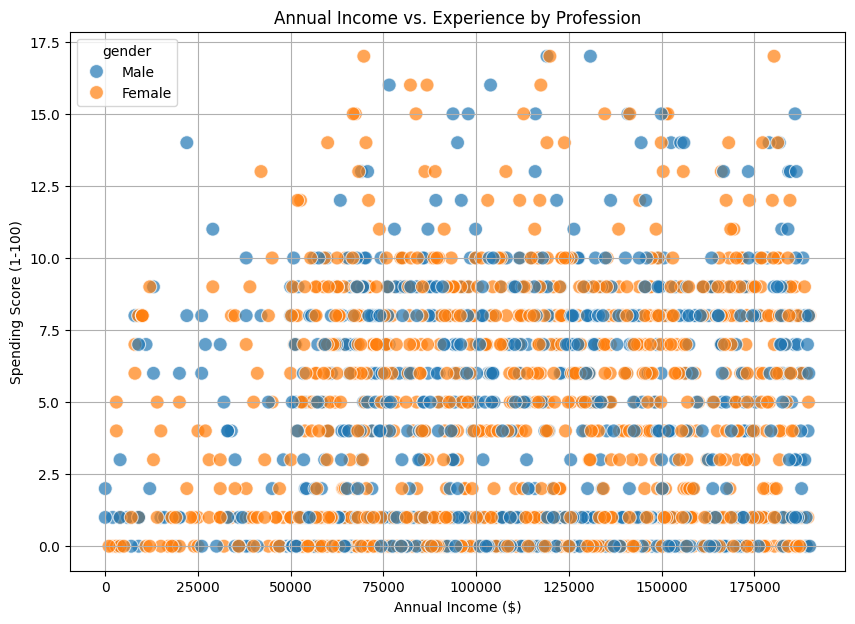

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='annual_income_($)', y='work_experience', hue='gender', data=df, s=100, alpha=0.7)
plt.title('Annual Income vs. Experience by Profession')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

**Part 2**

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target numbers to species names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Display first few rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [ ]:
print(df['species'].unique())

['setosa' 'versicolor' 'virginica']


In [ ]:
grouped = df.groupby('species')
stats = grouped.agg(['mean', 'std', 'min', 'max'])
print(stats)

           sepal length (cm)                     sepal width (cm)            \
                        mean       std  min  max             mean       std   
species                                                                       
setosa                 5.006  0.352490  4.3  5.8            3.428  0.379064   
versicolor             5.936  0.516171  4.9  7.0            2.770  0.313798   
virginica              6.588  0.635880  4.9  7.9            2.974  0.322497   

                     petal length (cm)                     petal width (cm)  \
            min  max              mean       std  min  max             mean   
species                                                                       
setosa      2.3  4.4             1.462  0.173664  1.0  1.9            0.246   
versicolor  2.0  3.4             4.260  0.469911  3.0  5.1            1.326   
virginica   2.2  3.8             5.552  0.551895  4.5  6.9            2.026   

                                
                 

In [ ]:
percentiles = grouped.quantile([0.25, 0.50, 0.75])
print(percentiles)

                 sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                                   
setosa     0.25              4.800             3.200              1.400   
           0.50              5.000             3.400              1.500   
           0.75              5.200             3.675              1.575   
versicolor 0.25              5.600             2.525              4.000   
           0.50              5.900             2.800              4.350   
           0.75              6.300             3.000              4.600   
virginica  0.25              6.225             2.800              5.100   
           0.50              6.500             3.000              5.550   
           0.75              6.900             3.175              5.875   

                 petal width (cm)  
species                            
setosa     0.25               0.2  
           0.50               0.2  
           0.75               

In [ ]:
print(grouped.describe())


           sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean       std  min  25%  50%  75%  max  
sp

<Figure size 1000x600 with 0 Axes>

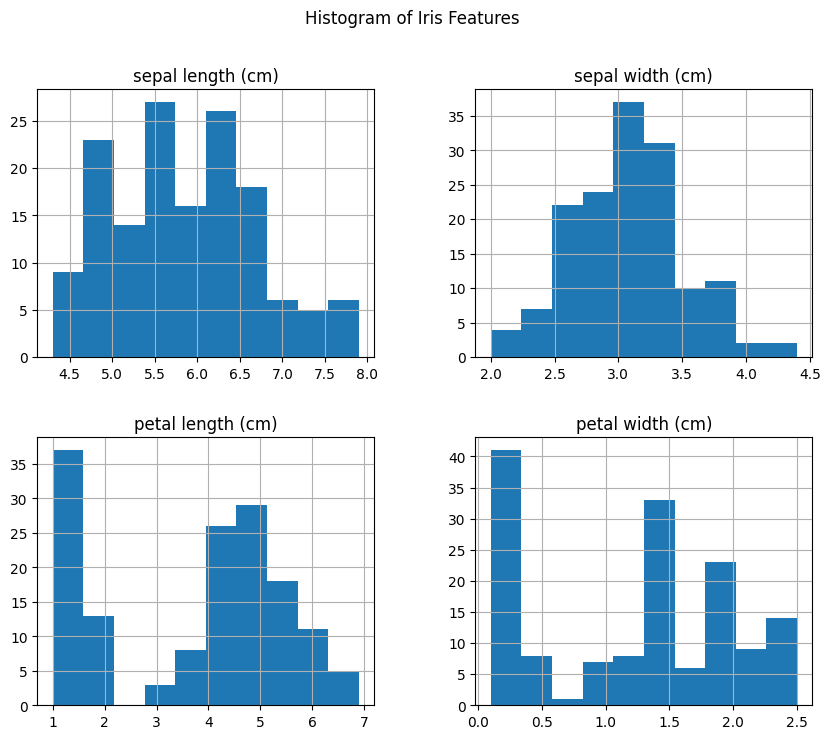

In [ ]:
plt.figure(figsize=(10,6))

df.hist(figsize=(10,8))
plt.suptitle("Histogram of Iris Features")
plt.show()

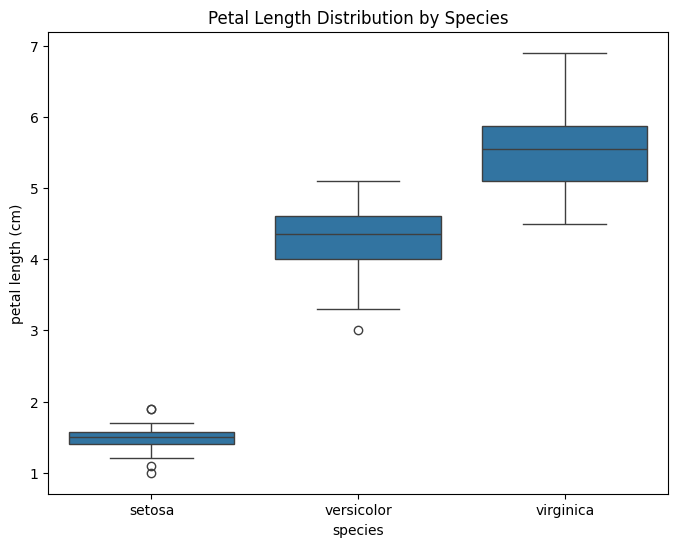

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x='species', y='petal length (cm)', data=df)

plt.title("Petal Length Distribution by Species")
plt.show()

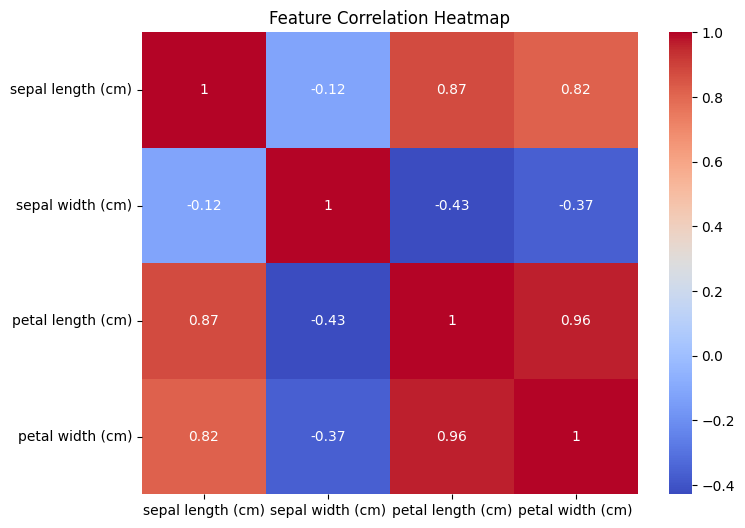

In [ ]:

plt.figure(figsize=(8,6))

corr = df.drop('species', axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

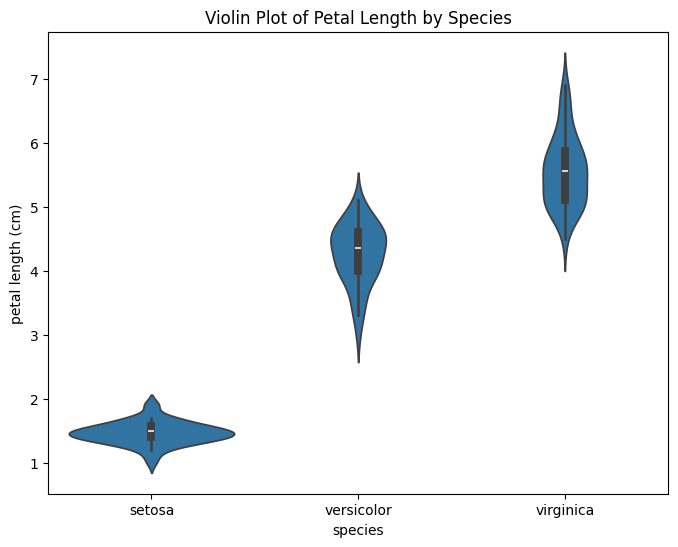

In [ ]:
plt.figure(figsize=(8,6))

sns.violinplot(x='species', y='petal length (cm)', data=df)

plt.title("Violin Plot of Petal Length by Species")
plt.show()

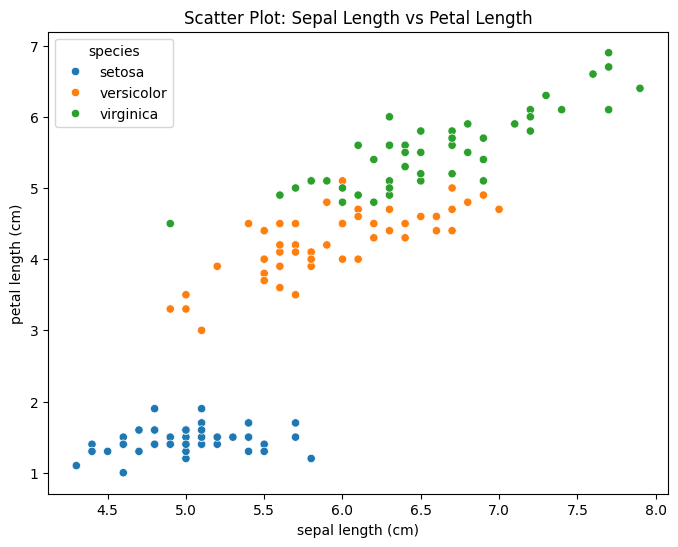

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',
    data=df
)

plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.show()